# Cross-Selling de Servicios

[Alejandro Morales](mailto:ja.moralesv@hotmail.com)

## Motivación

Este es un ejercicio de aplicación de Multi-Arm-Bandits y Optimización Bayesiana a un problema basado en una experiencia anterior.



In [3]:
%%capture
!pip install pyro-ppl

In [4]:
import torch
import pyro
import pyro.distributions as dist
import itertools
from pyro.infer import MCMC, NUTS

## Planteamento del Problema

### Contexto de Negocio

En una empresa de e-commerce se busca extender el negocio ofreciendo servicios adicionales como una forma de venta cruzada (cross-selling). Los servicios adicionales los ofrecen terceros que cobran un fee al e-commerce.

En el siguiente diagrama se muestran los ingredientes para una venta cruzada:
- Bolsa de Productos
- Bolsa de Servicios Adicionales: servicios ofrecidos por terceros altamente correlacionados con las categorias de los productos.
- Lista de Discounts: descuentos posibles para los Servicios Adicionales

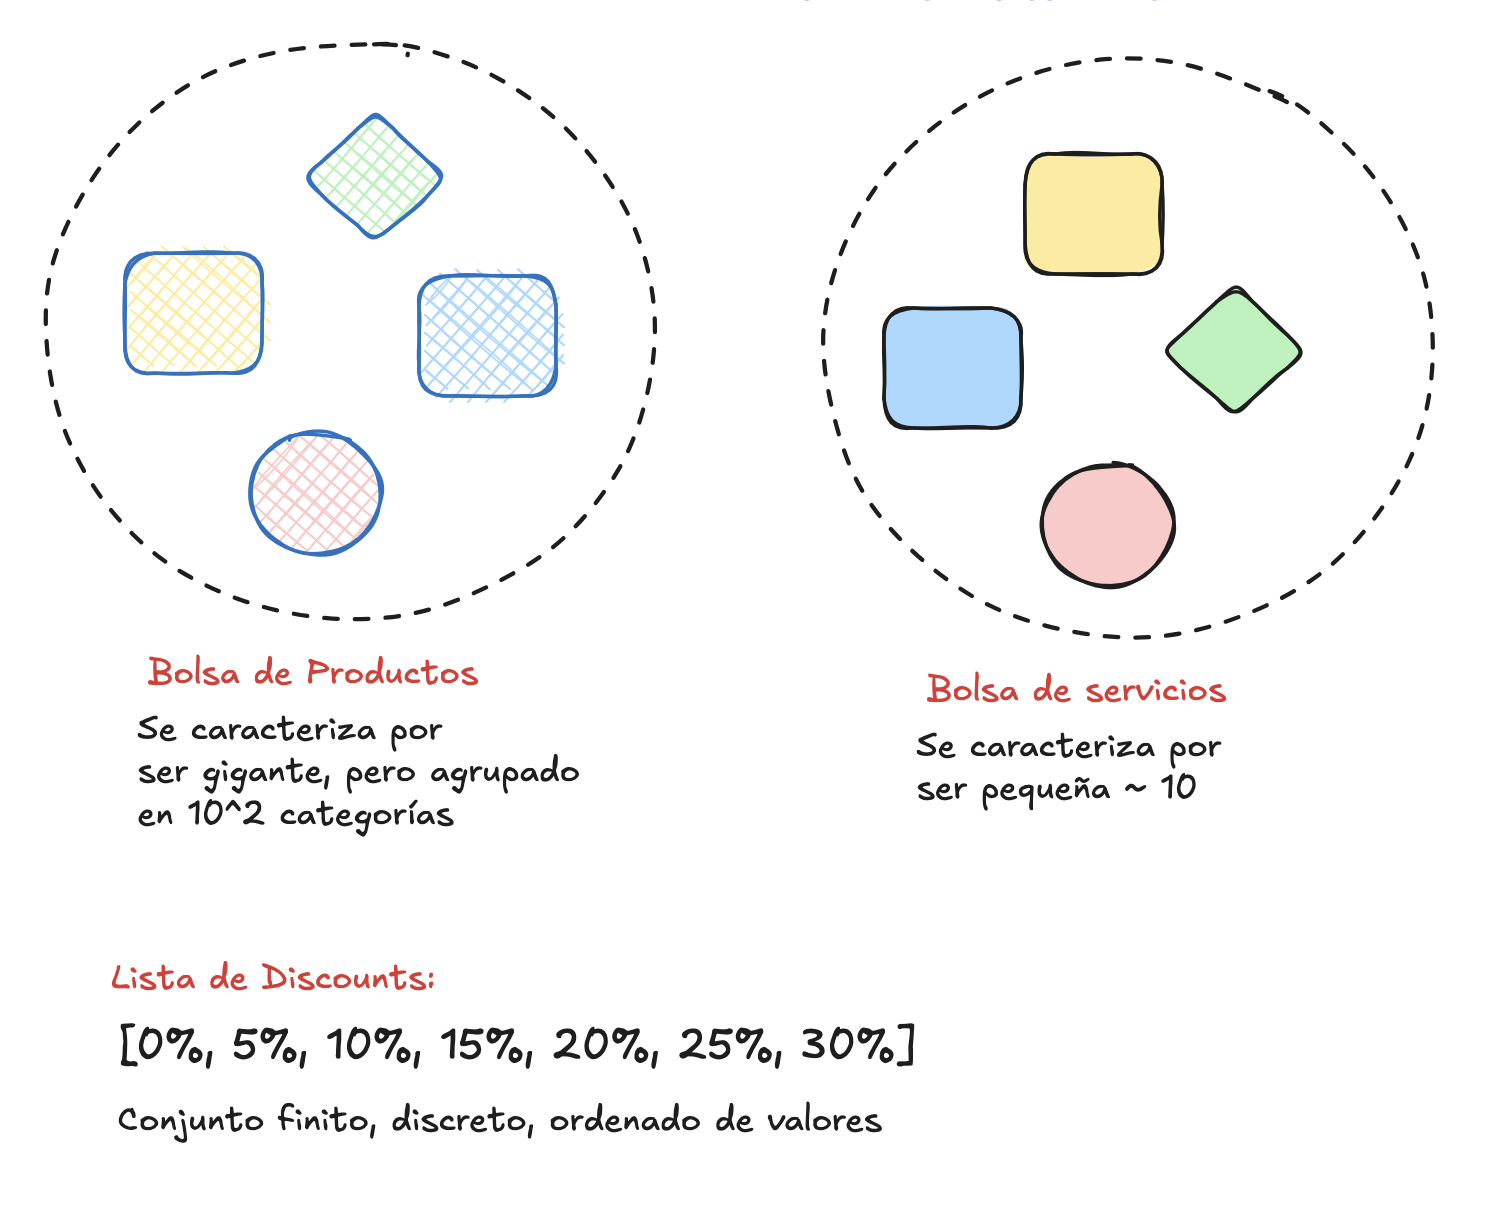

El viaje del Cliente dentro de la plataforma e-commerce, simplificado alrededor de la vista donde se ofrecen los Servicios Adicionales, se muestra a continuación.


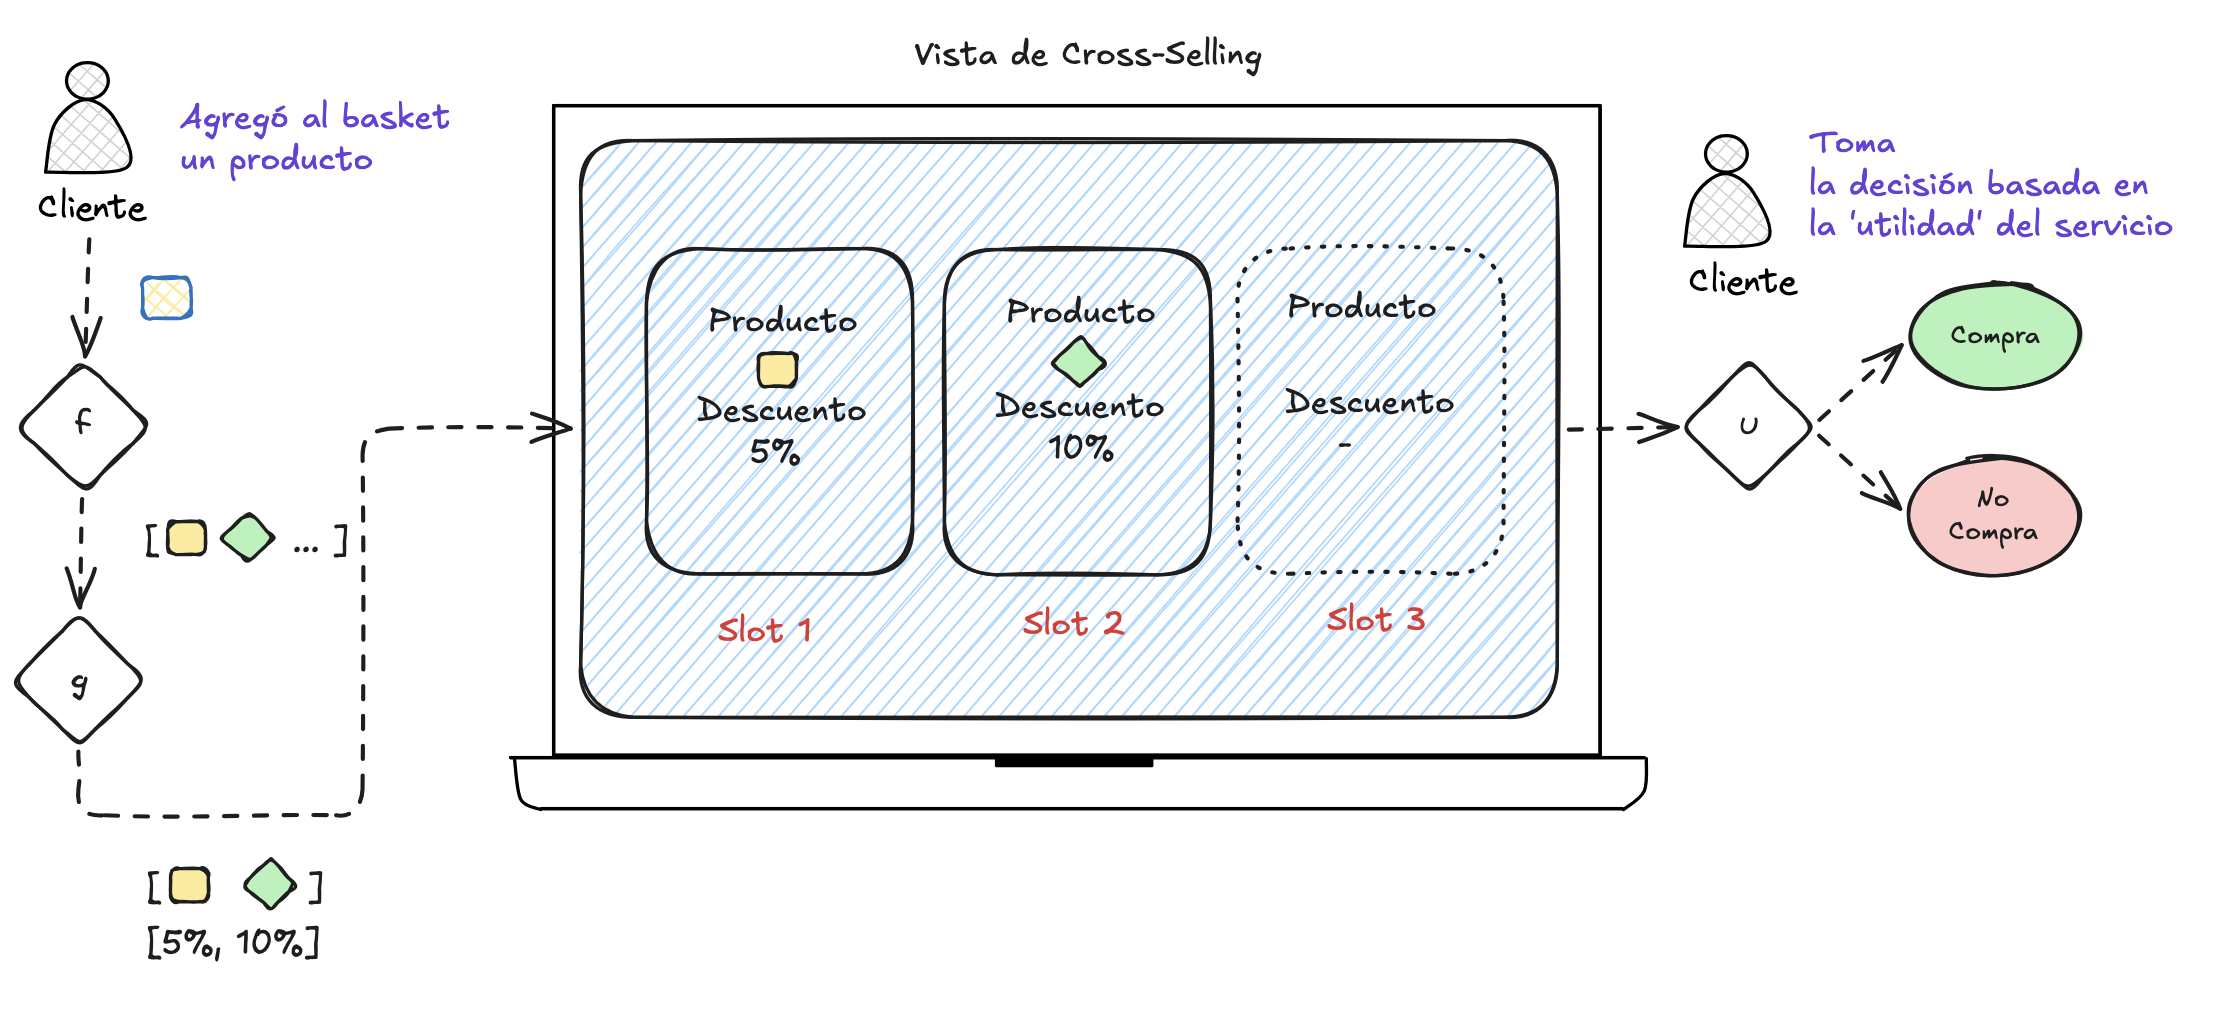

1. Se parte del hecho de que el Cliente ha seleccionado un producto de la `Bolsa de Productos`.
2. Una función `f` mapea el producto seleccionado a un conjunto de Servicios Adicionales potenciales. Este conjunto se selecciona teniendo en cuenta las reglas de negocio.
3. Una función `g` toma la lista de servicios potenciales, las reordena y filtra para finalmente asociarlas con un descuento.
4. La salida de la función `g` se renderiza en la vista de cross-selling donde se expone al Cliente.
5. El cliente hace una evaluación de Útilidad (modelado por la función de Útilidad Latente) y toma una decisión que puede resultar en `Compra` y `No Compra`

> Nota: El número de slots esta fijo en 3 por simplicidad, pero puede ser configurable.


### Definición del Problema

Dado el contexto de negocio que se presentó en el punto anterior, podemos definir el problema de la siguente manera:

¿Cuál es la secuencia de configuraciones (`Servicio`, `Descuento`) dado un `Producto` seleccionado previamente que **maximiza** el Revenue, a través de las ventas?

## Arquitectura de la Solución

Para la solución de este problema vamos a útilizar un enfoque de Optimización Bayesiana. Para ello vamos a explorar las funciones principales expuestas en la sección anterior, es decir `f`, `g` y `u`.

La función `f` esta implementada como un conjuno de regla que define la unidad de negocio. Por el momento hay poca oportunidad de maniobra para modificar esta función.

Por otro lado la función `g` representa el núcleo del problema. Para identificar esta función podriamos basarnos en una combinación de conocimiento previo de negocio y experimentación

TODO: Poner la definición de U

In [9]:
# 1. DEFINICIÓN DEL MODELO (Basado en Utilidad Latente de McFadden)
def model(product_idx, discounts, y=None):
    """
    product_idx: (N_obs, 3) -> Índices de los productos en cada slot
    discounts: (N_obs, 3) -> Valor del descuento [0, 1]
    y: (N_obs,) -> Slot elegido (0: Ninguno, 1: Slot1, 2: Slot2, 3: Slot3)
    """
    n_products = 5

    # Atractivo intrínseco de cada ítem
    alpha = pyro.sample("alpha", dist.Normal(0, 1).expand([n_products]).to_event(1))

    # Sensibilidad al descuento (forzamos a que sea positiva)
    beta = pyro.sample("beta", dist.HalfNormal(1.0))

    # Efecto de Contraste / Decoy (Interacción entre ítems del set)
    # Representa cuánto "brilla" un producto si los otros son peores
    gamma = pyro.sample("gamma", dist.Normal(0, 0.5))

    # Cálculo de Utilidad Latente V por slot
    # V_s = alpha_p + beta * log(1 + d_s) + gamma * (d_s - d_otros_promedio)
    d_mean = discounts.mean(dim=1, keepdim=True)
    v_slots = alpha[product_idx] + beta * torch.log1p(discounts) + gamma * (discounts - d_mean)

    # El Bridge: Opción de "No comprar" fija en 0
    u_no_purchase = torch.zeros(v_slots.shape[0], 1)
    logits = torch.cat([u_no_purchase, v_slots], dim=1)

    with pyro.plate("data", product_idx.shape[0]):
        pyro.sample("obs", dist.Categorical(logits=logits), obs=y)

In [8]:

# 2. THOMPSON SAMPLING PARA MAXIMIZAR REVENUE
def run_thompson_sampling(posterior_samples, bag_items, allowed_discounts, base_prices):
    """
    Selecciona la configuración (p1, p2, p3, d1, d2, d3) que maximiza el Revenue.
    """
    # Muestreamos UN escenario de la realidad según el posterior (Incertidumbre epistémica)
    sample_idx = torch.randint(0, len(posterior_samples['alpha']), (1,))
    s_alpha = posterior_samples['alpha'][sample_idx].squeeze()
    s_beta = posterior_samples['beta'][sample_idx]
    s_gamma = posterior_samples['gamma'][sample_idx]

    best_revenue = -1.0
    best_config = None

    # Generamos combinaciones legales: 3 ítems DIFERENTES
    product_combos = list(itertools.permutations(bag_items, 3))
    discount_combos = list(itertools.product(allowed_discounts, repeat=3))

    for p_set in product_combos:
        p_tensor = torch.tensor(p_set)
        for d_set in discount_combos:
            d_tensor = torch.tensor(d_set)

            # Cálculo de Utilidad con los parámetros muestreados
            d_mean = d_tensor.mean()
            v = s_alpha[p_tensor] + s_beta * torch.log1p(d_tensor) + s_gamma * (d_tensor - d_mean)

            # Convertir a probabilidades (Softmax) incluyendo la opción "No comprar" (0)
            logits = torch.cat([torch.tensor([0.0]), v])
            probs = torch.softmax(logits, dim=0) # [P_none, P_s1, P_s2, P_s3]

            # REVENUE ESPERADO: Suma de (Prob_compra_slot * Precio_final_slot)
            # Precio final = Base_Price * (1 - Descuento)
            current_prices = torch.tensor([base_prices[p] * (1 - d) for p, d in zip(p_set, d_set)])
            expected_revenue = torch.sum(probs[1:] * current_prices).item()

            if expected_revenue > best_revenue:
                best_revenue = expected_revenue
                best_config = (p_set, d_set)

    return best_config, best_revenue

# 3. CONFIGURACIÓN DE PRUEBA
bag = [0, 1, 2, 3, 4]
precios_base = {0: 100, 1: 80, 2: 120, 3: 50, 4: 200}
descuentos_permitidos = [0.05, 0.1, 0.2]

# Supongamos que ya corriste MCMC y tienes 'samples'
# samples = { 'alpha': torch.randn(1000, 5), 'beta': torch.rand(1000), 'gamma': torch.randn(1000) }